In [2]:
import math
import numpy as np
import statistics as stat
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
bgDataRaw = pd.read_csv('resources/Lab11BgCorrected.csv')
fiestaRaw = pd.read_csv('resources/Lab11FiestaRCorrected.csv')
fiestaAl1Raw = pd.read_csv('resources/Lab11FiestaAlCorrected.csv')
fiestaAl2Raw = pd.read_csv('resources/Lab11FiestaAl2Corrected.csv')
fiestaAl3Raw = pd.read_csv('resources/Lab11FiestaAl3Corrected.csv')

display(bgDataRaw)
display(fiestaRaw)
display(fiestaAl1Raw)
display(fiestaAl2Raw)
display(fiestaAl3Raw)

,elapsedTime,cps,totalCount,totalInts
0,0.000000,16,267860,6920
1,10.004687,22,268072,6930
2,20.012923,22,268300,6940
3,30.021069,24,268535,6950
4,40.029107,23,268777,6959
5,50.038075,26,268973,6969
6,60.046950,24,269187,6979
7,70.055748,27,269423,6989
8,80.064438,22,269664,6999
9,90.073048,19,269898,7009


,elapsedTime,cps,totalCount,totalInts
0,0.000008,55,243118,6266
1,10.008411,65,243652,6276
2,20.016675,45,244162,6286
3,30.024837,63,244675,6296
4,40.032922,63,245141,6305
5,50.041918,51,245673,6315
6,60.050823,52,246218,6325
7,70.059631,47,246752,6335
8,80.068348,50,247293,6345
9,90.076582,50,247806,6355


,elapsedTime,cps,totalCount,totalInts
0,0.000019,25,252478,6457
1,10.008292,38,252839,6467
2,20.016457,36,253174,6477
3,30.020600,42,253477,6486
4,40.029580,27,253843,6496
5,50.038471,41,254177,6506
6,60.047270,28,254523,6516
7,70.055973,46,254880,6526
8,80.064615,36,255215,6536
9,90.073094,45,255590,6546


,elapsedTime,cps,totalCount,totalInts
0,0.000006,27,257675,6607
1,10.008518,33,257976,6617
2,20.014249,25,258300,6627
3,30.022563,29,258589,6637
4,40.030781,27,258907,6647
5,50.038902,25,259159,6656
6,60.047946,31,259467,6666
7,70.056897,28,259768,6676
8,80.065748,31,260088,6686
9,90.074514,34,260409,6696


,elapsedTime,cps,totalCount,totalInts
0,0.000007,21,262552,6764
1,10.008583,29,262864,6774
2,20.017024,28,263227,6784
3,30.022774,40,263575,6794
4,40.031071,35,263944,6804
5,50.039269,42,264298,6814
6,60.047363,54,264631,6823
7,70.056386,28,264979,6833
8,80.065281,32,265341,6843
9,90.074121,30,265693,6853


In [4]:
bgData = pd.DataFrame()
bgData['elapsedTime'] = bgDataRaw['elapsedTime']
bgData['countPerInterval'] = bgDataRaw['totalCount'].diff().fillna(0)

fiestaRData = pd.DataFrame()
fiestaRData['elapsedTime'] = fiestaRaw['elapsedTime']
fiestaRData['countPerInterval'] = fiestaRaw['totalCount'].diff().fillna(0)

fiestaAl1Data = pd.DataFrame()
fiestaAl1Data['elapsedTime'] = fiestaAl1Raw['elapsedTime']
fiestaAl1Data['countPerInterval'] = fiestaAl1Raw['totalCount'].diff().fillna(0)

fiestaAl2Data = pd.DataFrame()
fiestaAl2Data['elapsedTime'] = fiestaAl2Raw['elapsedTime']
fiestaAl2Data['countPerInterval'] = fiestaAl2Raw['totalCount'].diff().fillna(0)

fiestaAl3Data = pd.DataFrame()
fiestaAl3Data['elapsedTime'] = fiestaAl3Raw['elapsedTime']
fiestaAl3Data['countPerInterval'] = fiestaAl3Raw['totalCount'].diff().fillna(0)

# display(bgData)
# display(fiestaRData)
# display(fiestaAl1Data)
# display(fiestaAl2Data)
# display(fiestaAl3Data)

In [5]:
fiestaData = pd.DataFrame()
fiestaData['elapsedTime'] = fiestaRaw['elapsedTime']
fiestaData['rawCPI'] = fiestaRData['countPerInterval']
fiestaData['Al1CPI'] = fiestaAl1Data['countPerInterval']
fiestaData['Al2CPI'] = fiestaAl2Data['countPerInterval']
fiestaData['Al3CPI'] = fiestaAl3Data['countPerInterval']

display(fiestaData)

,elapsedTime,rawCPI,Al1CPI,Al2CPI,Al3CPI
0,0.000008,0.0,0.0,0.0,0.0
1,10.008411,534.0,361.0,301.0,312.0
2,20.016675,510.0,335.0,324.0,363.0
3,30.024837,513.0,303.0,289.0,348.0
4,40.032922,466.0,366.0,318.0,369.0
5,50.041918,532.0,334.0,252.0,354.0
6,60.050823,545.0,346.0,308.0,333.0
7,70.059631,534.0,357.0,301.0,348.0
8,80.068348,541.0,335.0,320.0,362.0
9,90.076582,513.0,375.0,321.0,352.0


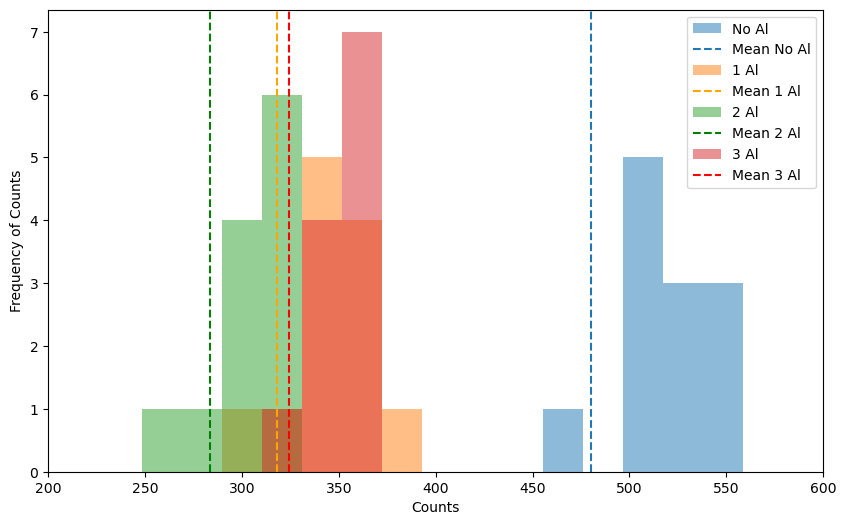

No Aluminum:   Mean = 480.31, Std Dev = 145.94
1 Al Sheet:    Mean = 318.00, Std Dev = 97.67
2 Al Sheets:   Mean = 283.62, Std Dev = 87.58
3 Al Sheets:   Mean = 324.31, Std Dev = 98.65


In [11]:
plt.figure(figsize = (10, 6))
plt.xlabel('Counts')
plt.ylabel('Frequency of Counts')
plt.xlim(200,600)
bins = np.linspace(0, 600, 30)

data0 = fiestaData['rawCPI']
mu0, std0 = data0.mean(), data0.std()
plt.hist(fiestaData['rawCPI'], alpha = 0.5, bins = bins, label = 'No Al')
plt.axvline(mu0, linestyle='--', label = 'Mean No Al')

data1 = fiestaData['Al1CPI']
mu1, std1 = data1.mean(), data1.std()
plt.hist(fiestaData['Al1CPI'], alpha = 0.5, bins = bins, label = '1 Al')
plt.axvline(mu1, color = 'orange', linestyle='--', label = 'Mean 1 Al')

data2 = fiestaData['Al2CPI']
mu2, std2 = data2.mean(), data2.std()
plt.hist(fiestaData['Al2CPI'], alpha = 0.5, bins = bins, label = '2 Al')
plt.axvline(mu2, color = 'green', linestyle='--', label = 'Mean 2 Al')

data3 = fiestaData['Al3CPI']
mu3, std3 = data3.mean(), data3.std()
plt.hist(fiestaData['Al3CPI'], alpha = 0.5, bins = bins, label = '3 Al')
plt.axvline(mu3, color = 'red', linestyle='--', label = 'Mean 3 Al')

plt.legend()
plt.show()

print(f"No Aluminum:   Mean = {fiestaData['rawCPI'].mean():.2f}, Std Dev = {fiestaData['rawCPI'].std():.2f}")
print(f"1 Al Sheet:    Mean = {fiestaData['Al1CPI'].mean():.2f}, Std Dev = {fiestaData['Al1CPI'].std():.2f}")
print(f"2 Al Sheets:   Mean = {fiestaData['Al2CPI'].mean():.2f}, Std Dev = {fiestaData['Al2CPI'].std():.2f}")
print(f"3 Al Sheets:   Mean = {fiestaData['Al3CPI'].mean():.2f}, Std Dev = {fiestaData['Al3CPI'].std():.2f}")

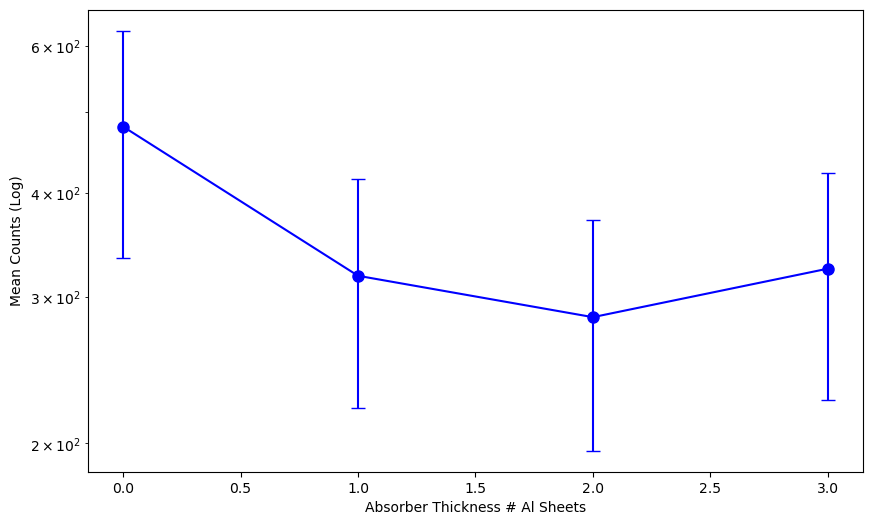

In [14]:
plt.figure(figsize = (10, 6))
thickness = [0, 1, 2, 3] # for # sheets
Almean = [fiestaData['rawCPI'].mean(), fiestaData['Al1CPI'].mean(), fiestaData['Al2CPI'].mean(), fiestaData['Al3CPI'].mean()]
Alstd = [fiestaData['rawCPI'].std(), fiestaData['Al1CPI'].std(), fiestaData['Al2CPI'].std(), fiestaData['Al3CPI'].std()]

plt.errorbar(thickness, Almean, yerr = Alstd, fmt = 'o-', capsize = 5, label = 'Error (Al)', color = 'blue', markersize = 8)
plt.yscale('log')
plt.xlabel('Absorber Thickness # Al Sheets')
plt.ylabel('Mean Counts (Log)')
plt.show()